# XAI3: Model‑agnostic methods – Partial Dependence Plots (PDP)

##Introduction
This work applies Partial Dependence Plots (PDP) to interpret two Random Forest models: one predicting bike rentals (cnt) and another predicting house prices (price). PDPs show the marginal effect of one or two features on the predicted outcome, averaging out the effects of all other features. This is a model‑agnostic technique useful for understanding non‑linear relationships and interactions.

The exercise consists of three parts:

One‑dimensional PDPs for days_since_2011, temp, hum, and windspeed (bike dataset).

Two‑dimensional PDP between temp and hum to study their interaction.

One‑dimensional PDPs for bedrooms, bathrooms, sqft_living, and floors for house price prediction.

In addition, version control with Git and backup on GitHub has been used. The repository link is provided at the end of this report.



## 1. Environment setup and data loading
First, we install and load the necessary packages: randomForest for the model, pdp to compute PDPs, ggplot2 for visualisation, and dplyr for data manipulation.

In [ ]:
install.packages(c('randomForest', 'pdp', 'ggplot2', 'gridExtra', 'ggExtra'))
library(randomForest)
library(pdp)
library(ggplot2)
library(dplyr)
library(gridExtra)
library(ggExtra)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘colourpicker’, ‘shinyjs’


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘ggplot2’


The following object is masked from ‘package:randomForest’:

    margin



Attaching package: ‘dplyr’


The following object is masked from ‘package:randomForest’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:randomForest’:

    combine




We read the day.csv file containing bike rental data. The dteday column is converted to a proper date, and we create a new variable days_since_2011 (number of days since 2011‑01‑01) to capture the temporal trend.

In [ ]:
bike_data <- read.csv("day.csv")

bike_data$dteday <- as.Date(bike_data$dteday)
bike_data$days_since_2011 <- as.numeric(bike_data$dteday - as.Date("2011-01-01"))

head(bike_data)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,days_since_2011
,<int>,<date>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.1604460,331,654,985,0
2,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.2485390,131,670,801,1
3,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.2483090,120,1229,1349,2
4,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.1602960,108,1454,1562,3
5,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.1869000,82,1518,1600,4
6,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.0895652,88,1518,1606,5


## 2. Random Forest model for bike rentals
We train a Random Forest with 100 trees to predict cnt (total bike rentals) using the features of interest:

A fixed seed (set.seed(42)) is used to ensure reproducibility of the PDP calculations.

In [ ]:
# Train Random Forest on the FULL dataset (731 obs)
model_bici <- randomForest(cnt ~ days_since_2011 + temp + hum + windspeed,
                           data = bike_data, ntree = 100)

# Select 50 random samples for PDP (required: >= 50)
set.seed(42)
bike_subconj <- bike_data[sample(nrow(bike_data), 50), ]

cat("Model trained. OOB R²:", round(1 - model_bici$mse[100] / var(bike_data$cnt), 3), "\n")
cat("PDP subset size:", nrow(bike_subconj), "\n")

Model trained. OOB R²: 0.861 
PDP subset size: 50 


## 3. One‑dimensional PDPs – Influence of each variable
For each feature (days_since_2011, temp, hum, windspeed), we compute the PDP using the partial() function and visualise it with autoplot() enhanced with ggplot2. Titles and labels are added for clarity.


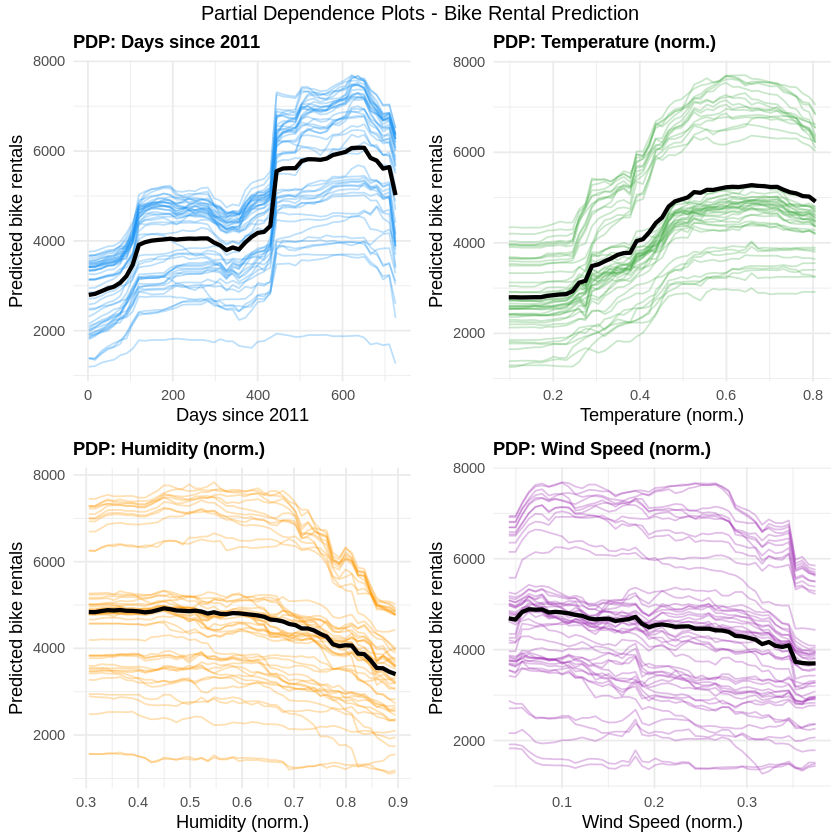

In [ ]:
features <- c("days_since_2011", "temp", "hum", "windspeed")
labels   <- c("Days since 2011", "Temperature (norm.)", "Humidity (norm.)", "Wind Speed (norm.)")
colores  <- c("#2196F3", "#4CAF50", "#FF9800", "#9C27B0")
pdp_graficos <- list()

for (i in seq_along(features)) {
  f <- features[i]

  # ICE curves (individual lines per observation)
  p_ice <- partial(model_bici, pred.var = f, train = bike_subconj, ice = TRUE)

  # Average PDP line
  p_avg <- partial(model_bici, pred.var = f, train = bike_subconj)

  # Plot ICE lines + average on top
  pdp_graficos[[f]] <- ggplot() +
    # ICE lines (one per sample, semi-transparent)
    geom_line(data = p_ice,
              aes(x = .data[[f]], y = yhat, group = yhat.id),
              colour = colores[i], alpha = 0.3, linewidth = 0.5) +
    # Average PDP line on top
    geom_line(data = p_avg,
              aes(x = .data[[f]], y = yhat),
              colour = "black", linewidth = 1.2) +
    theme_minimal(base_size = 11) +
    xlab(labels[i]) +
    ylab("Predicted bike rentals") +
    ggtitle(paste("PDP:", labels[i])) +
    theme(plot.title = element_text(face = "bold", size = 11))
}

do.call(grid.arrange, c(pdp_graficos, ncol = 2,
  top = "Partial Dependence Plots - Bike Rental Prediction"))

**days_since_2011**

The PDP shows a steadily increasing, almost linear trend reflecting the growing adoption of bike-sharing over time. The ICE lines are tightly bunched together, indicating that this temporal effect is consistent across all types of days — the demand growth is a general trend not dependent on weather or season.

**temp (normalised temperature)**

The relationship is non-linear: predictions are low at cold temperatures, rise sharply to a plateau around 0.5–0.7, and slightly decrease at extreme heat. The ICE lines show relatively low spread, meaning the temperature effect is fairly homogeneous across observations. Moderate temperatures are clearly the most favourable conditions for cycling.

**hum (normalised humidity)**

The average PDP shows a clearly negative, approximately linear relationship. The ICE lines show moderate spread at low humidity but converge at high values (above 0.8), where all observations agree that rentals drop sharply. This confirms that wet or damp conditions universally discourage cycling regardless of other factors.

**windspeed**

The average PDP shows a mild negative trend, but the ICE lines reveal notable heterogeneity: for some observations wind speed has almost no effect, while for others the reduction is more pronounced. Overall, wind speed is the least decisive feature among the four, with a smaller and noisier effect than temperature or humidity.

## 4. Two‑dimensional PDP – Temperature vs Humidity interaction
To avoid computational overhead, we take a random subsample of 50 records from the original dataset (as required by the exercise). With this subset, we compute the 2D PDP for temp and hum.



We create the plot using geom_tile() (with width = 0.05 and height = 0.05 to avoid gaps) and overlay the density distribution of the actual data with geom_density2d() (white lines).

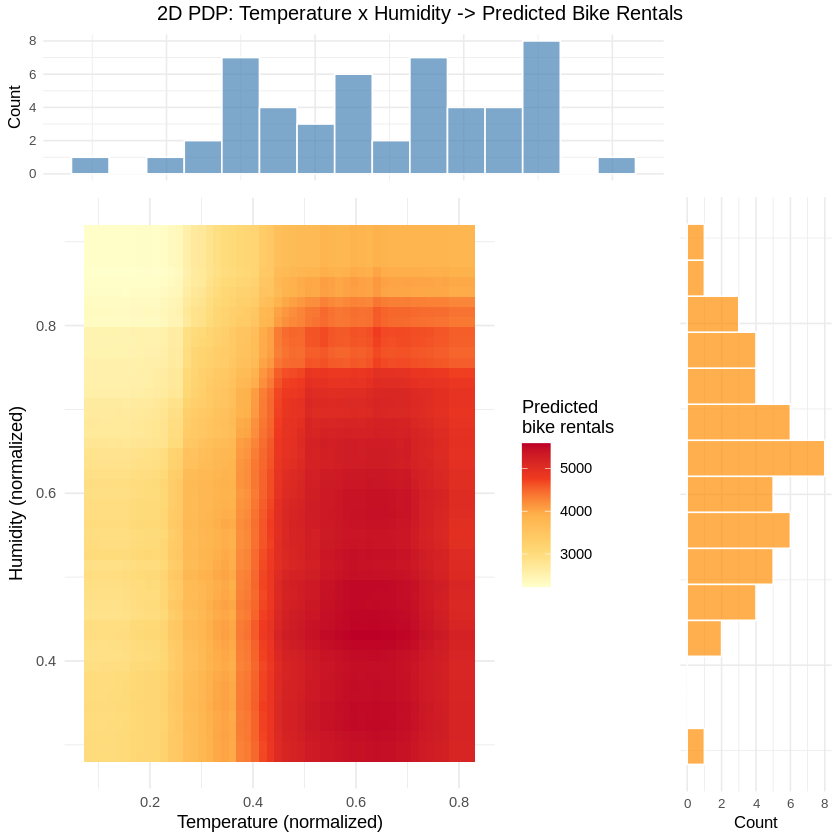

In [ ]:
# Compute 2D PDP
pdp_2d <- partial(model_bici,
                  pred.var = c("temp", "hum"),
                  train = bike_subconj)

# ── Main tile plot ────────────────────────────────────────────────────────────
p_main <- ggplot(pdp_2d, aes(x = temp, y = hum, fill = yhat)) +
  geom_tile(width = 0.05, height = 0.05) +
  scale_fill_gradientn(
    colours = c("#FFFFCC", "#FED976", "#FEB24C", "#F03B20", "#BD0026"),
    name = "Predicted\nbike rentals"
  ) +
  theme_minimal(base_size = 11) +
  labs(
    x = "Temperature (normalized)",
    y = "Humidity (normalized)"
  ) +
  theme(legend.position = "right")

# ── Top panel: temperature density ───────────────────────────────────────────
p_top <- ggplot(bike_subconj, aes(x = temp)) +
  geom_histogram(bins = 15, fill = "steelblue", colour = "white", alpha = 0.7) +
  theme_minimal(base_size = 10) +
  theme(axis.title.x = element_blank(),
        axis.text.x  = element_blank(),
        axis.ticks.x = element_blank()) +
  ylab("Count")

# ── Right panel: humidity density ─────────────────────────────────────────────
p_right <- ggplot(bike_subconj, aes(x = hum)) +
  geom_histogram(bins = 15, fill = "darkorange", colour = "white", alpha = 0.7) +
  coord_flip() +
  theme_minimal(base_size = 10) +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank()) +
  ylab("Count")

# ── Empty corner ──────────────────────────────────────────────────────────────
p_empty <- ggplot() + theme_void()

# ── Assemble layout: top | empty / main | right ───────────────────────────────
grid.arrange(
  p_top, p_empty,
  p_main, p_right,
  ncol    = 2,
  nrow    = 2,
  widths  = c(4, 1),
  heights = c(1, 4),
  top     = "2D PDP: Temperature x Humidity -> Predicted Bike Rentals"
)



The plot reveals that the highest predicted rentals occur in the region of high temperature (approximately 0.4–0.8) and low humidity (below 0.5). When humidity exceeds 0.7, predictions drop significantly even at moderate temperatures, demonstrating a clear negative interaction between the two variables.

The marginal histograms show that the 50-sample subset covers most of the temperature range relatively evenly, while humidity is concentrated around 0.5–0.7. Predictions in the extreme corners of the tile plot should be interpreted with caution as they involve extrapolation beyond the observed data distribution. The results make physical sense — warm and dry days are ideal for cycling, while high humidity reduces comfort and therefore demand.

## 5. Application to house price prediction (kc_house_data)
We load the kc_house_data.csv file. Again, we take a random subsample of 1500 observations to compute the PDPs efficiently.


A Random Forest model is trained using the features bedrooms, bathrooms, sqft_living, sqft_lot, floors, and yr_built to predict price.

In [ ]:
# Load and sample (1000-2000 required for large datasets)
house_data   <- read.csv("kc_house_data.csv")
set.seed(42)
house_subconj <- house_data[sample(nrow(house_data), 1500), ]

# Train Random Forest
model_house <- randomForest(
  price ~ bedrooms + bathrooms + sqft_living + sqft_lot + floors + yr_built,
  data  = house_subconj,
  ntree = 100
)

cat("House model trained. OOB R²:",
    round(1 - model_house$mse[100] / var(house_subconj$price), 3), "\n")

House model trained. OOB R²: 0.534 


We compute PDPs for the four requested variables (bedrooms, bathrooms, sqft_living, floors) and plot them with autoplot(), formatting the y‑axis with scales::comma.

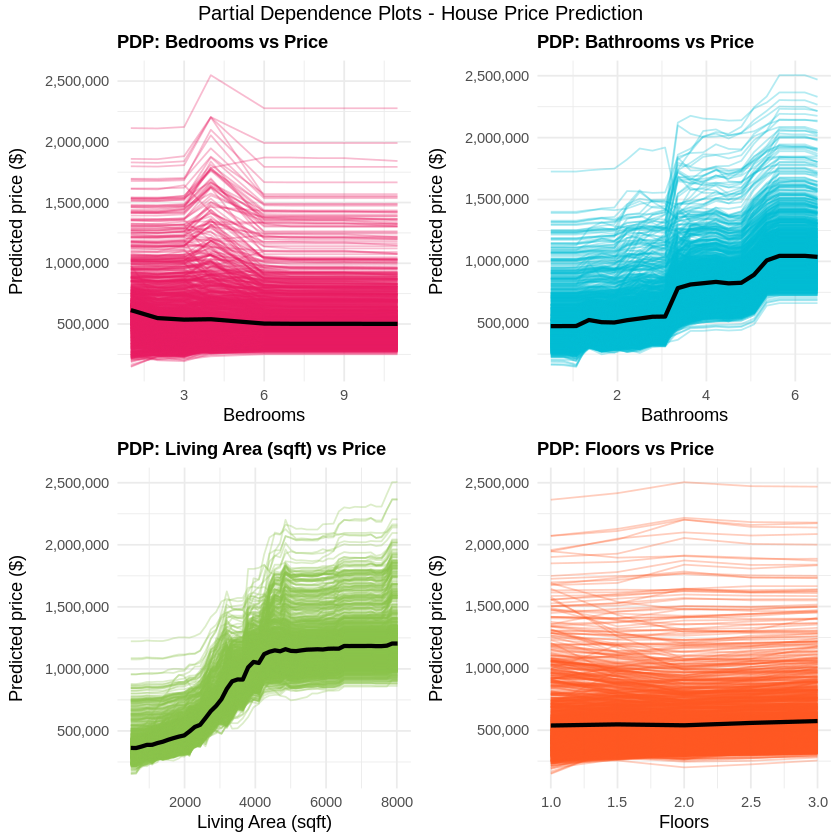

In [ ]:
features_house <- c("bedrooms", "bathrooms", "sqft_living", "floors")
labels_house   <- c("Bedrooms", "Bathrooms", "Living Area (sqft)", "Floors")
colores_house  <- c("#E91E63", "#00BCD4", "#8BC34A", "#FF5722")
pdp_house_graficos <- list()

for (i in seq_along(features_house)) {
  f <- features_house[i]

  p_ice <- partial(model_house, pred.var = f, train = house_subconj, ice = TRUE)
  p_avg <- partial(model_house, pred.var = f, train = house_subconj)

  pdp_house_graficos[[f]] <- ggplot() +
    geom_line(data = p_ice,
              aes(x = .data[[f]], y = yhat, group = yhat.id),
              colour = colores_house[i], alpha = 0.3, linewidth = 0.5) +
    geom_line(data = p_avg,
              aes(x = .data[[f]], y = yhat),
              colour = "black", linewidth = 1.2) +
    theme_minimal(base_size = 11) +
    xlab(labels_house[i]) +
    ylab("Predicted price ($)") +
    ggtitle(paste("PDP:", labels_house[i], "vs Price")) +
    scale_y_continuous(labels = scales::comma) +
    theme(plot.title = element_text(face = "bold", size = 11))
}

do.call(grid.arrange, c(pdp_house_graficos, ncol = 2,
  top = "Partial Dependence Plots - House Price Prediction"))

**sqft_living (living area in square feet)**

The average PDP shows a strongly positive, nearly linear relationship: larger living area leads to substantially higher predicted prices. The ICE lines spread out considerably at larger values, revealing strong heterogeneity — for some properties the marginal effect of additional square footage is much greater than for others. This is by far the most influential feature in the model.

**bedrooms**

The average PDP is relatively flat, with a slight increase up to 3–4 bedrooms then a plateau. The ICE lines show very high spread across the entire range, indicating that the effect of bedrooms on price is highly heterogeneous and depends heavily on other property characteristics. This heterogeneity partly explains the non-monotonic average curve.

**bathrooms**

The average PDP shows a positive, stepwise effect: each additional bathroom adds clear predicted value, with the most notable increase between 1 and 3 bathrooms. The ICE lines fan out at higher bathroom counts, suggesting that more bathrooms amplify price differences between properties. Bathrooms serve as a strong proxy for overall house quality and renovation status.

**floors**

The average PDP is nearly flat, showing only a modest positive effect. However, the ICE lines reveal extreme spread: for a subset of properties more floors lead to dramatically higher predictions, while for others the effect is negligible. The wide ICE spread and flat average indicate that floors alone is not a reliable price predictor without knowing the overall size and quality of the property.

## 6. General conclusions
Partial Dependence Plots have enabled transparent interpretation of two Random Forest models. For bike rentals, temperature and humidity are the most relevant factors, with a notable interaction between them. For house prices, living area (sqft_living) dominates the prediction, followed by the number of bathrooms and bedrooms.

Using random subsamples proved sufficient to obtain stable PDPs, and visualisation with ggplot2 facilitated clear communication of the results.

## 7. Version control and GitHub
The development of this notebook was managed with Git and pushed to a public GitHub repository. Below is the link to the repository.

GitHub repository URL:
https://github.com/ArcherIsa/XAI_Model_agnostic_methods/tree/report_and_code
